In [1]:
import pandas as pd 

from matplotlib import pyplot as plt

In [86]:
def load_data(dataset, task_id, layer, basis_name, relevance_from):

    return pd.read_csv(f"./artifacts/{dataset}/task-{task_id}/{layer}/relevance-{relevance_from}/{basis_name}Basis.csv")

load_data(
    dataset="multinist",
    task_id=0,
    layer="act3",
    basis_name="PRCARecon",
    relevance_from="lrp"
)

,layer,task_id,logit_mod,gamma,k,basis_name,recon_err,rel_recon_err,perc_sign_align,acc_test,xent_test
0,act3,0,winning-class,0.25,5,PRCAReconBasis,58.539500,0.505081,0.539175,0.2309,3.305107
1,act3,0,winning-class,0.25,10,PRCAReconBasis,54.304940,0.275596,0.578698,0.5751,1.431269
2,act3,0,winning-class,0.25,15,PRCAReconBasis,50.541283,0.165949,0.599305,0.7093,0.986183
3,act3,0,winning-class,0.25,20,PRCAReconBasis,47.230410,0.109280,0.615265,0.7577,0.796275


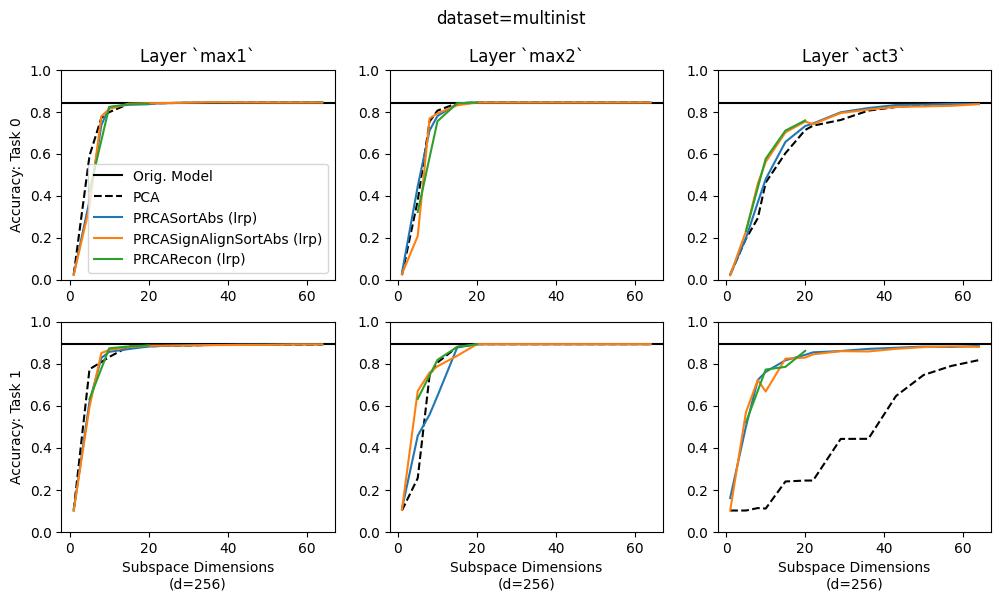

In [129]:
def viz(
    dataset="multinist",
    arr_basis_names=[
        ("PCA", "lrp"), 
        ("PRCASortAbs", "lrp"),
    ],
    arr_task_ids=[0, 1],
    arr_layers=["max1", "max2", "act3"],
    mapping_ls_color_marker= dict(
        PCA=("--", "blue", None),
        PCALookAhead=("-", "blue", None)
    ),
    perf_col="acc_test"
):
    nrows = len(arr_task_ids)
    ncols = len(arr_layers)

    max_k = 64

    def _ls_color_marker(basis_name, relevance_from):
        
        return mapping_ls_color_marker.get(f"{basis_name}_{relevance_from}", ("-", None, None))
        

    def _label(basis_name, relevance_from):
        if "PCA" in basis_name:
            return basis_name
        else:
            return f"{basis_name} ({relevance_from})"
    

    col_name = {
        "acc_test": "Accuracy",
        "val_auroc": "AUROC",
    }[perf_col]
    
    plt.figure(figsize=(4*ncols, 3*nrows))
    plt.suptitle(f"dataset={dataset}")
    for lix, layer in enumerate(arr_layers):
        for tix, task_id in enumerate(arr_task_ids):
        
            plt.subplot(nrows, ncols,  tix * ncols + lix + 1)
            plt.ylim([0, 1])
            for bix, (basis_name, relevance_from) in enumerate(arr_basis_names):
                    
                df = load_data(
                    dataset=dataset,
                    task_id=task_id,
                    layer=layer,
                    basis_name=basis_name,
                    relevance_from=relevance_from
                )
                if bix == 0:
                    __df = load_data(
                        dataset=dataset,
                        task_id=task_id,
                        layer=layer,
                        basis_name="PCA",
                        relevance_from=relevance_from
                    )
                    d = __df.k.values[-1]
                    
                    plt.axhline(__df[perf_col].values[-1], ls="-", color="k", label="Orig. Model")
                selected = df.k <= max_k

                ls, color, marker = _ls_color_marker(basis_name, relevance_from)
                plt.plot(
                    df.k[selected],
                    df[perf_col][selected],
                    label=_label(basis_name, relevance_from),
                    ls=ls,
                    color=color,
                    marker=marker
                )

                            
            if tix == 0:
                plt.title(f"Layer `{layer}`")

            if lix == 0:
                plt.ylabel(f"{col_name}: Task {task_id}")

            if tix == nrows - 1:
                plt.xlabel(f"Subspace Dimensions\n(d={d})")
                
            if lix == 0 and tix == 0:
                plt.legend()

 
        # PCA_lrp=("--", "blue", None),
        # PCALookAhead_lrp=("-", "blue", "*"),
        # PRCASortAbs_lrp=("--", "red", None),
        # PRCAReconGreedy_lrp=("-", "red", None),
        # PRCARecon_lrp=("-", "red", "*"),
    
viz(arr_basis_names=[
        ("PCA", "lrp"),
        ("PRCASortAbs", "lrp"),
        ("PRCASignAlignSortAbs", "lrp"),
        ("PRCARecon", "lrp")
    ], mapping_ls_color_marker=dict(PCA_lrp=("--", "black", None))
)

In [100]:
# viz(arr_basis_names=[
#         ("PRCASortAbs", "grad"),
#         ("PRCASignAlignSortAbs", "grad"),
#         ("PRCARecon", "grad")
#     ], mapping_ls_color_marker=dict(PCA_lrp=("--", "black", None))
# )

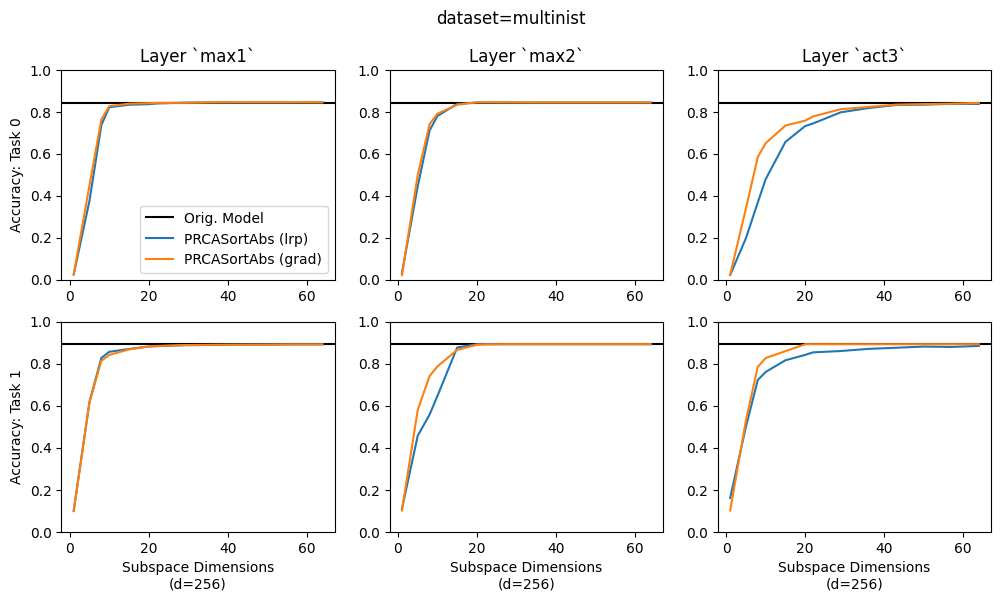

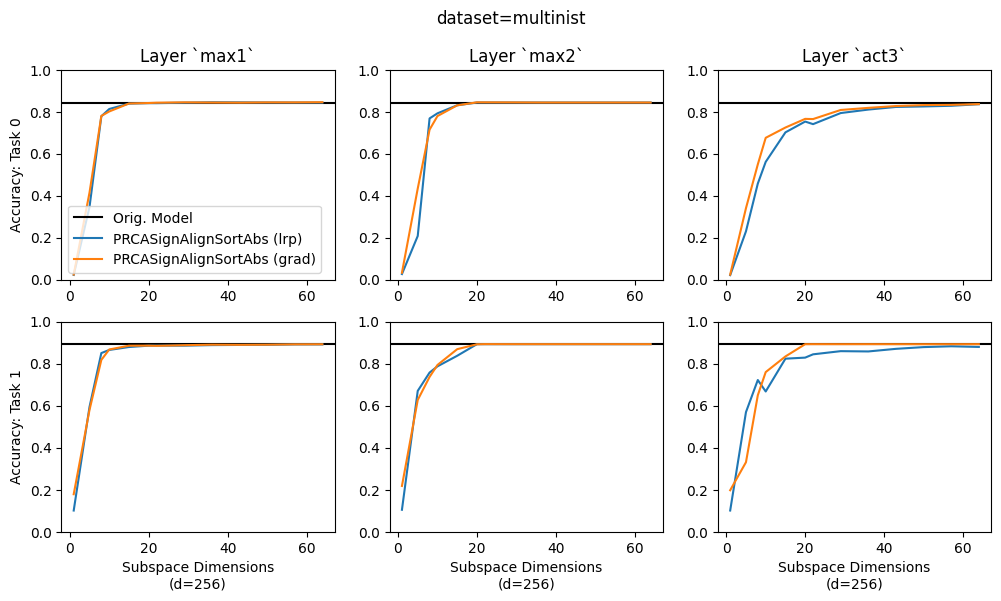

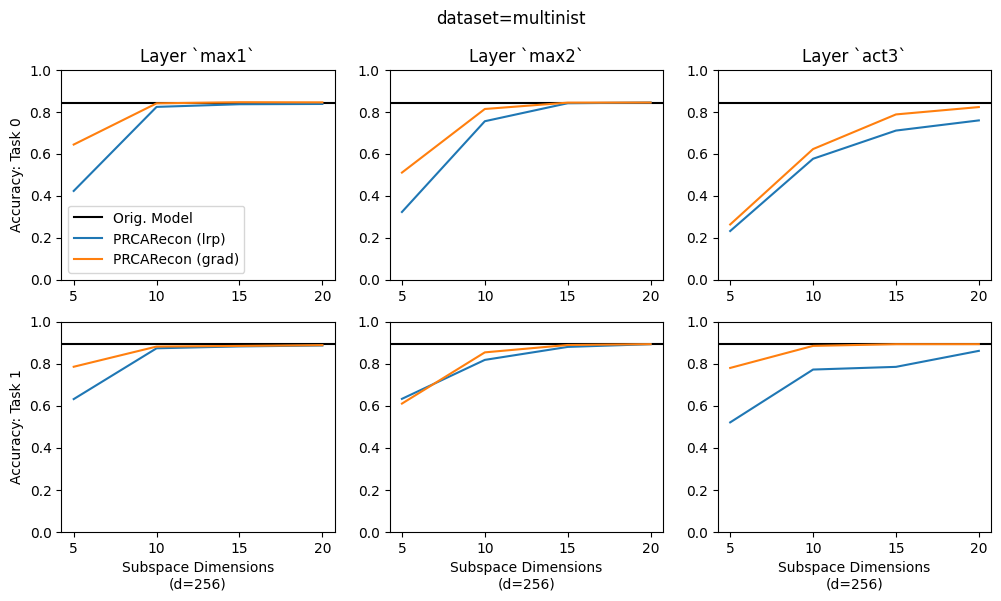

In [132]:
for basis_name in ["PRCASortAbs", "PRCASignAlignSortAbs",  "PRCARecon"]:
        
    viz(arr_basis_names=[
            # ("PCA", "lrp"),
            (basis_name, "lrp"),
            (basis_name, "grad"),
        ], mapping_ls_color_marker=dict(PCA_lrp=("--", "black", None))
    )

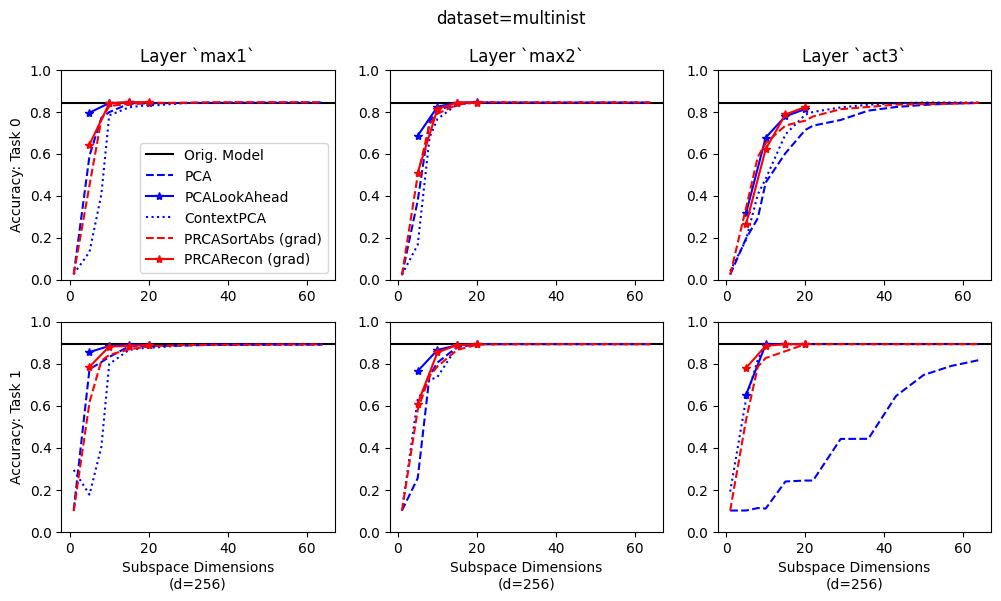

In [139]:
viz(arr_basis_names=[
        ("PCA", "grad"), 
                            
        ("PCALookAhead", "grad"),
        ("ContextPCA", "grad"),
    
        ("PRCASortAbs", "grad"),
        ("PRCARecon", "grad")
    ], mapping_ls_color_marker=dict(
        PCA_grad=("--", "blue", None),
        PCALookAhead_grad=("-", "blue", "*"),
        ContextPCA_grad=(":", "blue", None),
        PRCASortAbs_grad=("--", "red", None),
        PRCARecon_grad=("-", "red", "*"),
    )
)

# CelebA

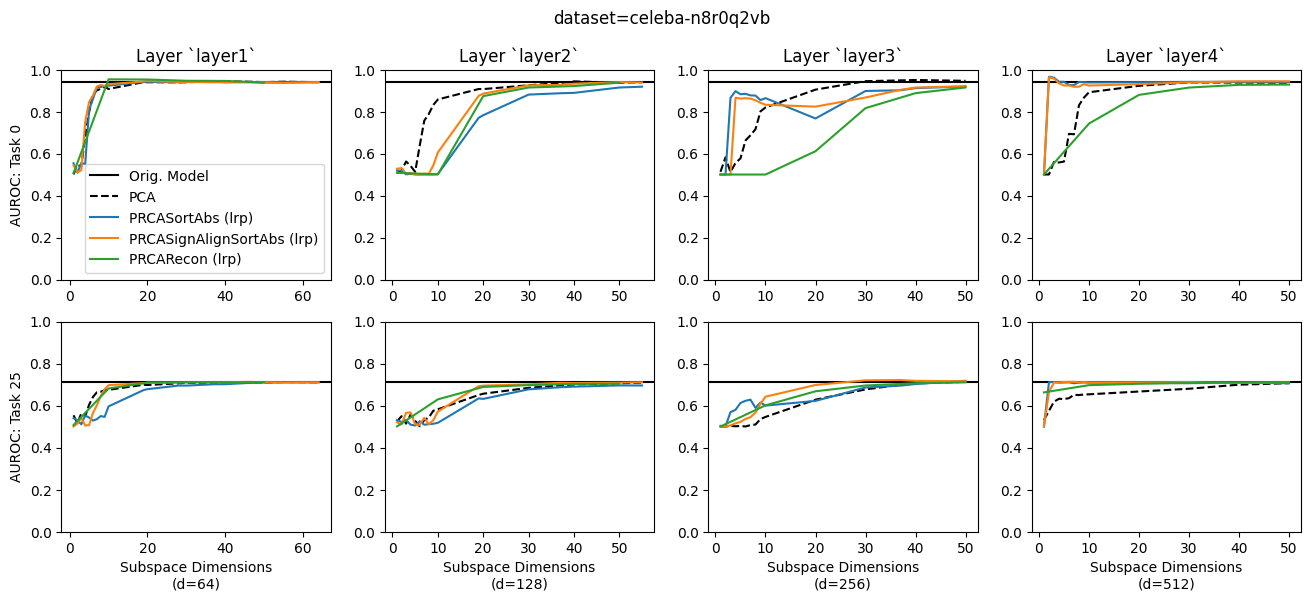

In [134]:
viz(
    dataset="celeba-n8r0q2vb",
    perf_col="val_auroc",
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    arr_task_ids=[0, 25],
    arr_basis_names=[
        ("PCA", "lrp"),
        ("PRCASortAbs", "lrp"),
        ("PRCASignAlignSortAbs", "lrp"),
        ("PRCARecon", "lrp")
    ], mapping_ls_color_marker=dict(PCA_lrp=("--", "black", None))
)

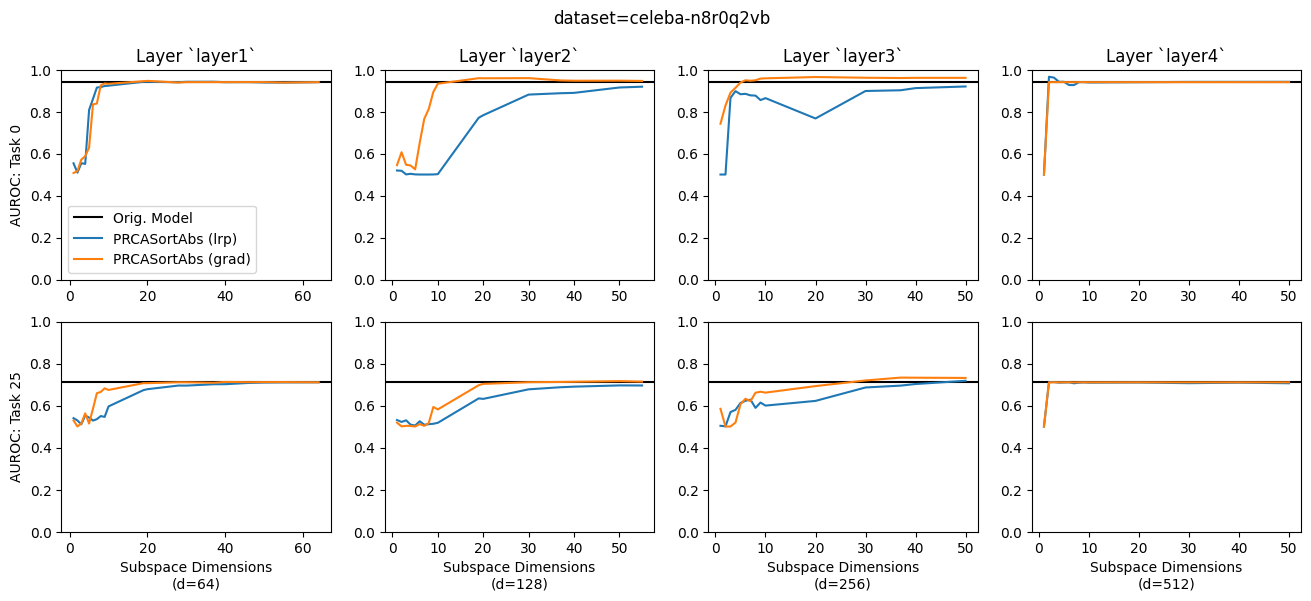

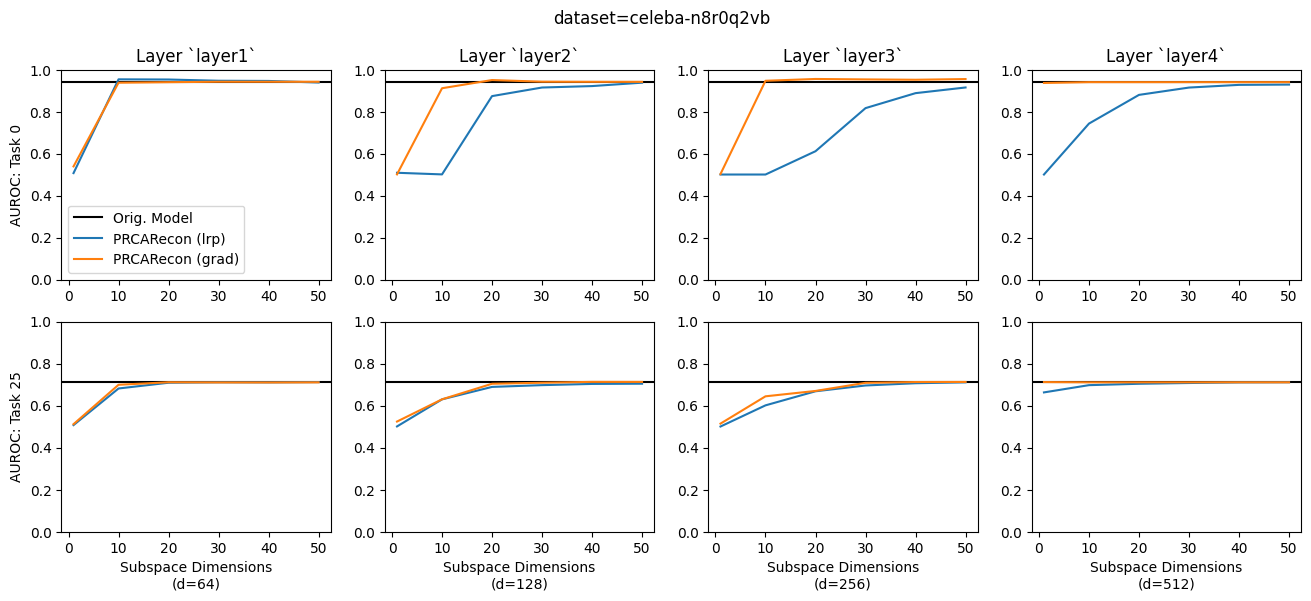

In [137]:
for basis_name in ["PRCASortAbs", "PRCARecon"]:
        
    viz(
        dataset="celeba-n8r0q2vb",
        arr_layers=["layer1", "layer2", "layer3", "layer4"],
        perf_col="val_auroc",
        arr_task_ids=[0, 25],
        arr_basis_names=[
            (basis_name, "lrp"),
            (basis_name, "grad"),
        ], mapping_ls_color_marker=dict(PCA_lrp=("--", "black", None))
    )

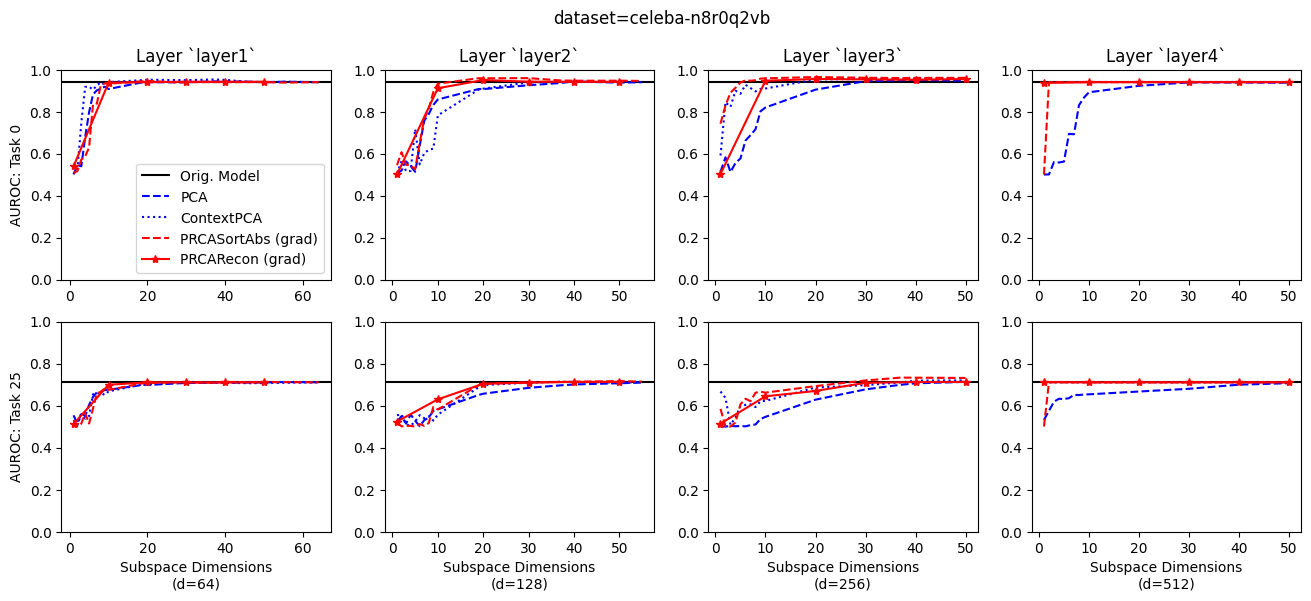

In [138]:
viz(
    dataset="celeba-n8r0q2vb",
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    perf_col="val_auroc",
    arr_task_ids=[0, 25],
    arr_basis_names=[
        ("PCA", "grad"), 
                            
        # ("PCALookAhead", "grad"),
        ("ContextPCA", "grad"),
    
        ("PRCASortAbs", "grad"),
        ("PRCARecon", "grad")
    ], mapping_ls_color_marker=dict(
        PCA_grad=("--", "blue", None),
        PCALookAhead_grad=("-", "blue", "*"),
        ContextPCA_grad=(":", "blue", None),
        PRCASortAbs_grad=("--", "red", None),
        PRCARecon_grad=("-", "red", "*"),
    )
)